## Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random 

## Memory-based policy-gradient model

We assume that the policy, i.e., the probability of choosing an option, is given by a 3-parameter logistic function:  
(1)  
$$\pi\left(chosen\right)=\frac{1}{1+\exp{\left[-\beta\left(\theta_{chosen}-\theta_{unchosen}\right)\right]}}$$
  
where $\theta_{chosen}$ and $\theta_{unchosen}$ are the “action propensities” for the soon-to-be-chosen and soon-to-be-unchosen actions, respectively. An action propensity is the tendency to select one option over the other, and it is the difference between them that determines which option is selected. The difference is scaled by the inverse temperature parameter $\beta$ which controls choice stochasticity. If the agent chooses their preferred action and observes a reward $r$, the model updates the policy parameters according to:  
(2)  
$$\Delta\theta=\alpha\left(r-V\right)\nabla_\theta\pi$$
  
where $\alpha$ is a learning rate, $V=E_\pi\left[V\right]\ =\pi\left(chosen\right)V_{chosen}+\pi\left(unchosen\right)V_{unchosen}$ is the policy-weighted average of the mean reward for each action, and $\nabla_\theta\pi$ is the gradient of the policy with respect to its propensity parameters. For the logistic policy of Eq. 1, this gradient contains two partial derivatives:  
(3)
$$\nabla_{\theta_{chosen}}\pi=\beta\pi\left(chosen\right)\left[1-\pi\left(chosen\right)\right]$$
(4)
$$\nabla_{\theta_{unchosen}}\pi=-\beta\pi\left(chosen\right)\left[1-\pi\left(chosen\right)\right]$$

The partial derivatives point in opposite directions, and therefore increasing the propensity for the chosen option will decrease the propensity of the unchosen option, and vice versa. This is a result of choosing the standard logistic policy parametrized by the difference between the two options’ action propensities ($\theta_{chosen}$ - $\theta_{unchosen}$). Such a policy is intuitive: it roughly amounts to the common practice of fitting a logistic regression model to subjects’ binary choices based on the difference between their assigned values.  

The model in its current formulation assumes perfect memory of the choice options. To account for imperfect memory, we let p(chosen, unchosen) denote a joint distribution of actions, representing the probability of recalling the chosen and unchosen options together. In order to match to the experimental procedure from Biderman & Shohamy (2021), we consider the case where we observe the outcome for the chosen option and then update the unchosen option (hence we condition on the chosen option):  
(5)
$$E\left[\nabla_{\theta_{unchosen}}\pi\middle| c h o s e n\right]=-\beta\pi\left(chosen\right)\left[1-\pi\left(chosen\right)\right]p\left(unchosen\middle|chosen\right)$$

This equation shows that the inverse decision bias should increase with conditional probability of recalling the unchosen option when presented with the chosen option, $p(chosen|unchosen)$.

In [11]:
class MemoryPolicyGradient:
    """Implements a policy gradient model with sigmoidal policy a function of the difference between propensities """
    def __init__(self, beta, learning_rate, theta_chosen_init, theta_unchosen_init, cumulative_reward_chosen, p_memory_unchosen_given_chosen, use_memory): 
        self.beta = beta
        self.learning_rate = learning_rate
        self.theta_chosen = theta_chosen_init
        self.theta_unchosen = theta_unchosen_init
        self.cumulative_reward_chosen = cumulative_reward_chosen
        self.p_memory_unchosen_given_chosen = p_memory_unchosen_given_chosen 
        self.use_memory = use_memory
    
    @staticmethod
    def sigmoid(x): 
        # define a general sigmoid function
        return 1./(1. + np.exp(-x))
    
    # eq.1
    def p_choose_chosen(self):
        # define the policy for choosing a, which is a sigmoid of the parameters of interest
        return self.sigmoid(self.beta*(self.theta_chosen - self.theta_unchosen))

    # eq.3
    def partial_chosen(self):
        # define the partial derivative of p_choose_chosen with respect to theta_chosen
        # note: theta_unchosen  = -1.*theta_chosen
        pi_chosen = self.p_choose_chosen()
        return self.beta*pi_chosen*(1. - pi_chosen)
    
    # eq. 3,4,7
    def gradient(self):
        # all the drama happens here: the gradient updates are opposite (stemming from the choice of p_choose_a)
        grad = np.array([self.partial_chosen(), -1.*self.partial_chosen()])
        # here we add the memory component for the unchosen item
        if self.use_memory:
            #grad[0] = grad[0] * self.p_memory_chosen 
            grad[1] = grad[1] * self.p_memory_unchosen_given_chosen
        return grad
    
    # eq. 2
    def average_reward(self):
        # V = self.p_choose_a()*self.average_reward_a + (1. - self.p_choose_a())*self.average_reward_b
        # V = self.p_choose_a()*self.cumulative_reward_a
        V = self.cumulative_reward_chosen
        return V
    
    # eq. 2
    def theta_update(self, reward_chosen):
        grad = self.gradient()
        return self.learning_rate*(reward_chosen - self.average_reward())*grad
    
    # eq. 3+4
    def theta_step(self, reward_chosen):
        update = self.theta_update(reward_chosen)
        self.theta_chosen += update[0]
        self.theta_unchosen += update[1]
    
        

## Testing the model

### general checkups 
We first make sure the sigmoid function works well.
Then, we want to make sure the model works. So we initialize thetas with the same value and want to see there is no preference for either a or b. 

In [3]:
memory_model = MemoryPolicyGradient(beta = 0.5, 
                                   learning_rate = 0.1, 
                                   theta_chosen_init = 1, 
                                   theta_unchosen_init = 1, 
                                   cumulative_reward_chosen = 5., 
                                   p_memory_unchosen_given_chosen = 1,
                                   use_memory = 1)


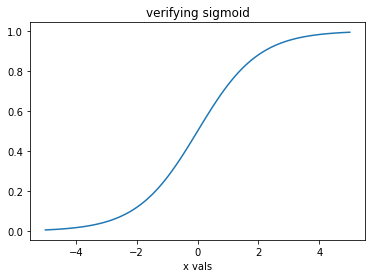

In [6]:
x = np.linspace(-5., 5., 100)
plt.plot(x, memory_model.sigmoid(x))
plt.title('verifying sigmoid')
plt.xlabel('x vals');

In [7]:
assert(memory_model.p_choose_chosen() == .5) # when we initialize with theta_chosen = theta_unchosen = .5, there's no preference

### Assess how different reward values affect the propensities of the chosen and unchosen options 
Here we assume perfect memory of the choice set. We get a perfect inverse symmetry in propensities. That is, the larger the reward, the stronger is the propensity for the chosen item and the weaker is for the unchosen item. Note that the change in propensity is relative to the cumulative reward of the chosen item. 

In [24]:
#rewards = np.array([18., 7.5, 30., 0., 1.])
rewards = np.linspace(0, 100, 100)
thetas = pd.DataFrame();
for i in range(len(rewards)):
    curr_memory_model = MemoryPolicyGradient(beta = 0.5, 
                                             learning_rate = 0.1, 
                                             theta_chosen_init = .5, 
                                             theta_unchosen_init = .5, 
                                             cumulative_reward_chosen = 50, 
                                             p_memory_unchosen_given_chosen = 1,
                                             use_memory = 1)
    curr_memory_model.theta_step(reward_chosen = rewards[i])
    thetas.loc[i,"reward_chosen"] = rewards[i]
    thetas.loc[i,"theta_chosen"] = curr_memory_model.theta_chosen
    thetas.loc[i,"theta_unchosen"] = curr_memory_model.theta_unchosen   


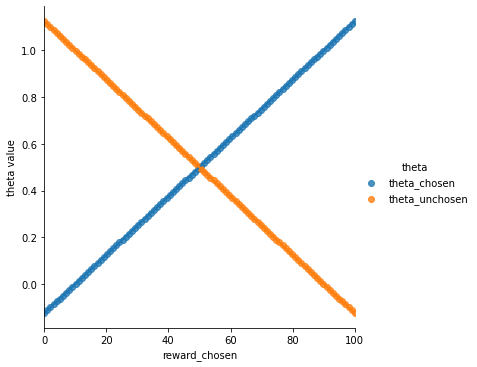

In [25]:
thetas_melt = pd.melt(thetas, 
                 id_vars='reward_chosen',
                 value_vars=['theta_chosen', 'theta_unchosen'],
                 var_name='theta', 
                 value_name='theta value')
sns.lmplot(data=thetas_melt, x="reward_chosen", y="theta value", hue="theta", ci=None);

### Manipulate memory and reward 
Here we want to see what happens to the propensities when we change the memory and the reward together. We indeed see a nice interaction between these parameters.
1. for unchosen items, memory increases the effect of reward on the inverse propensity. 
2. for chosen items, only reward affects the propensity in a linear fashion. 
3. note that the effect of reward is dependent on the average reward of items. Because the average reward is 5 for both the chosen and unchosen items, we do not see a positive value for the unchosen item and a negative value for the chosen item. when reward is zero, we see a slight preference towards the unchosen item. 



In [26]:
pair_memory = np.linspace(0, 1, 100) 
reward = np.array([0,50,100,150])
propensities_memory = np.empty((len(pair_memory), 4, len(reward)));

for j in range(len(reward)): 
    for i in range(len(pair_memory)):
        memory_model = MemoryPolicyGradient(beta = 0.5, 
                                            learning_rate = 0.1, 
                                            theta_chosen_init = .5, 
                                            theta_unchosen_init = .5, 
                                            cumulative_reward_chosen = 5., 
                                            p_memory_unchosen_given_chosen = pair_memory[i],
                                            use_memory = 1)
        memory_model.theta_step(reward_chosen = reward[j])
        # add to df
        propensities_memory[i,0,j] = pair_memory[i]
        propensities_memory[i,1,j] = reward[j]
        propensities_memory[i,2,j] = memory_model.theta_chosen
        propensities_memory[i,3,j] = memory_model.theta_unchosen


In [27]:
propensities_memory_df = pd.DataFrame()
for j in range(len(reward)):    
    propensities_memory_df = propensities_memory_df.append(pd.DataFrame(propensities_memory[:,:,j], 
                                                                        columns=["pair_memory", "reward", "theta_chosen", "theta_unchosen"]))
propensities_memory_df_melt = pd.melt(propensities_memory_df, 
                                     id_vars=['pair_memory','reward'],
                                     value_vars=['theta_chosen', 'theta_unchosen'],
                                     var_name='theta', 
                                     value_name='theta value')
#propensities_memory_df_melt

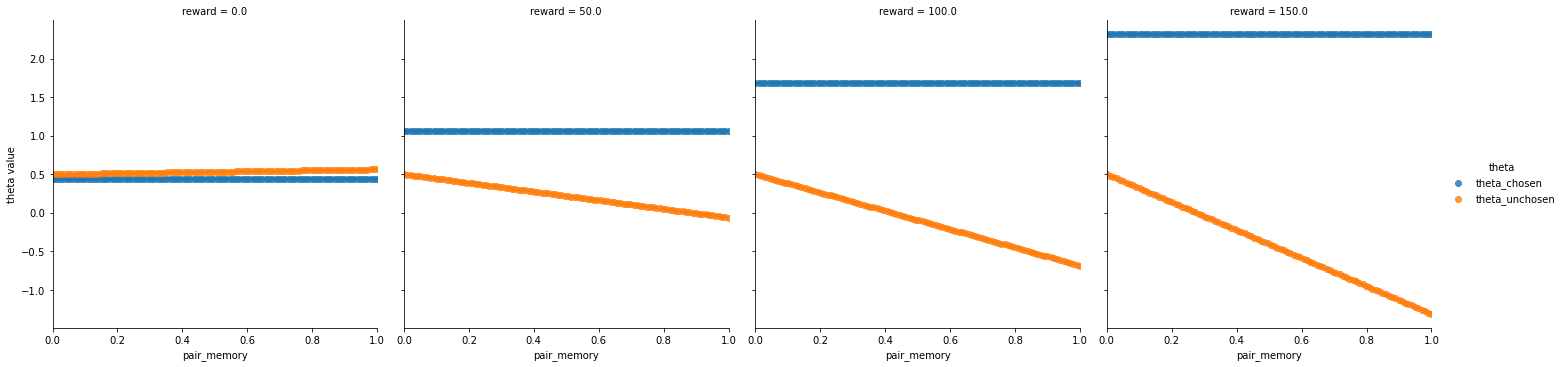

In [28]:
sns.lmplot(data=propensities_memory_df_melt, x="pair_memory", y="theta value", hue="theta", col="reward", ci=None);


### Manipulate average reward 
Here we want to see what happens when we change the cumulative experienced reward. The important point is that if the given reward is smaller than the average reward, then the propensity of the unchosen item is higher than that of the chosen item, and vice versa. 
What matters is the difference between the average reward and the given reward (rather than the ratio or absolute numbers of each). For example, the quantity  $|\theta_a - \theta_b|$ is the same whether $V = 0$ and $r = 1000$ and whether $V = 1000$ and $r = 0$ 

In [29]:
reward = np.linspace(0, 1000, 100) 
ave_reward = np.array([0,100,500,1000])
propensities_ave_reward = np.empty((len(reward), 4, len(ave_reward)));

for j in range(len(ave_reward)): 
    for i in range(len(reward)):
        memory_model_ave_reward = MemoryPolicyGradient(beta = 0.5, 
                                                       learning_rate = 0.1, 
                                                       theta_chosen_init = .5, 
                                                       theta_unchosen_init = .5, 
                                                       cumulative_reward_chosen = ave_reward[j], 
                                                       p_memory_unchosen_given_chosen = 1,
                                                       use_memory = 1)
        memory_model_ave_reward.theta_step(reward_chosen = reward[i])
        # add to df
        propensities_ave_reward[i,0,j] = ave_reward[j]
        propensities_ave_reward[i,1,j] = reward[i]
        propensities_ave_reward[i,2,j] = memory_model_ave_reward.theta_chosen
        propensities_ave_reward[i,3,j] = memory_model_ave_reward.theta_unchosen


In [30]:
propensities_ave_reward_df = pd.DataFrame()
for j in range(len(ave_reward)):    
    propensities_ave_reward_df = propensities_ave_reward_df.append(pd.DataFrame(propensities_ave_reward[:,:,j], 
                                                                                columns=["average_reward", "reward", "theta_chosen", "theta_unchosen"]))
propensities_ave_reward_df_melt = pd.melt(propensities_ave_reward_df, 
                                     id_vars=['average_reward','reward'],
                                     value_vars=['theta_chosen', 'theta_unchosen'],
                                     var_name='theta', 
                                     value_name='theta value')

propensities_ave_reward_df_melt["r_minus_V"] = propensities_ave_reward_df_melt["reward"] - propensities_ave_reward_df_melt["average_reward"]

#propensities_ave_reward_df_melt

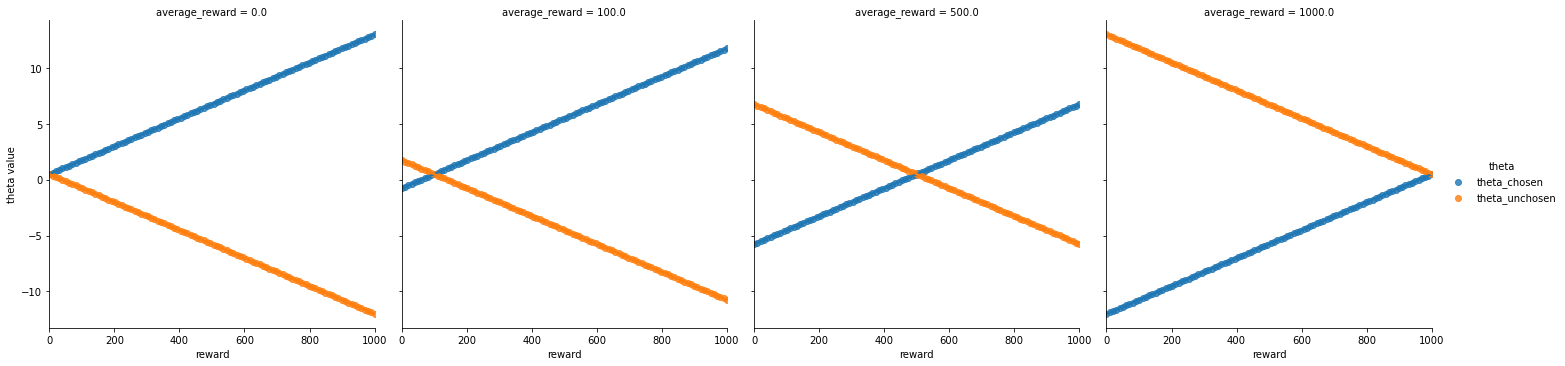

In [31]:
sns.lmplot(data=propensities_ave_reward_df_melt, x="reward", y="theta value", hue="theta", col="average_reward", ci=None);

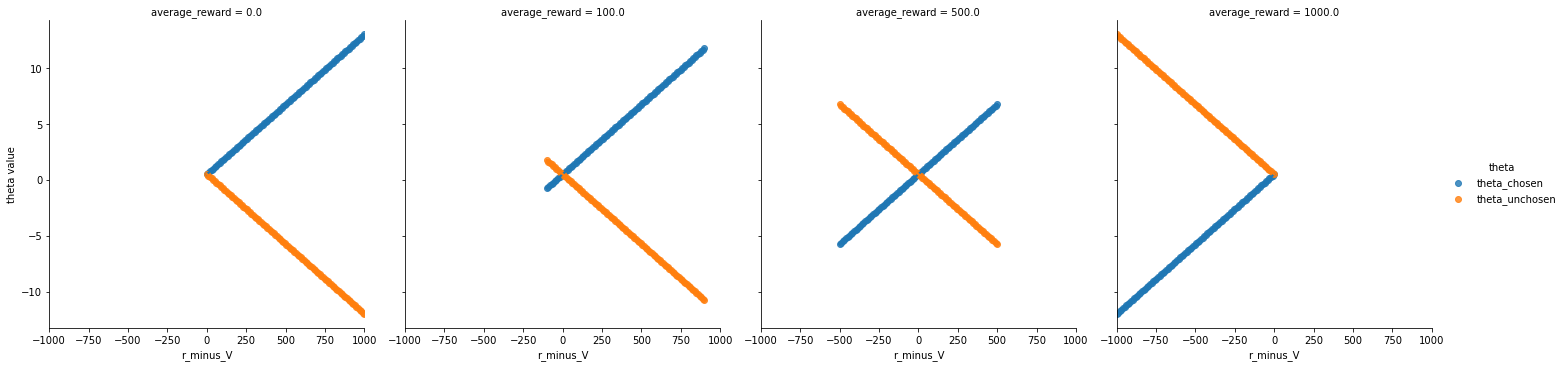

In [32]:
# plot
sns.lmplot(data=propensities_ave_reward_df_melt, x="r_minus_V", y="theta value", hue="theta", col="average_reward", ci=None);


## Fit model to simulated data

We first create simulated data that corresponds to our experimental data frames

In [34]:
n_pairs = 12
from sklearn.utils import shuffle

sim_df = pd.DataFrame({"init_val_chosen": np.random.randint(low=30, high=70, size=(n_pairs,)),
                       "init_val_unchosen": np.random.randint(low=30, high=70, size=(n_pairs,)),
                       "chosen_stim": np.random.choice(range(0,50), n_pairs, replace=False),
                       "unchosen_stim": np.random.choice(range(51,100), n_pairs, replace=False),
                       "reward": shuffle(np.repeat([0,150], n_pairs/2)),
                       "pairs_memory": shuffle(np.repeat([0,0.5,1], n_pairs/3)),
                       "theta_chosen": np.repeat(np.nan, n_pairs),
                       "theta_unchosen": np.repeat(np.nan, n_pairs)})


run the model on each pair 

In [35]:
learning_rate = 0.5
beta = 0.5

for i in range(len(sim_df)):
    # run the model
    curr_memory_model = MemoryPolicyGradient(beta = beta, 
                                             learning_rate = learning_rate, 
                                             theta_chosen_init = sim_df.init_val_chosen[i], 
                                             theta_unchosen_init = sim_df.init_val_unchosen[i], 
                                             cumulative_reward_chosen = np.mean(sim_df.reward), 
                                             p_memory_unchosen_given_chosen = sim_df.pairs_memory[i],
                                             use_memory = 1)
    curr_memory_model.theta_step(reward_chosen = sim_df.reward[i])
    # update theta according to the model
    sim_df.theta_chosen[i] = curr_memory_model.theta_chosen
    sim_df.theta_unchosen[i] = curr_memory_model.theta_unchosen


<ipython-input-35-1e9f60edb37f>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sim_df.theta_chosen[i] = curr_memory_model.theta_chosen
<ipython-input-35-1e9f60edb37f>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sim_df.theta_unchosen[i] = curr_memory_model.theta_unchosen


In [36]:
sim_df

,init_val_chosen,init_val_unchosen,chosen_stim,unchosen_stim,reward,pairs_memory,theta_chosen,theta_unchosen
0,38,65,28,85,150,1.0,38.000026,64.999974
1,42,30,8,77,0,0.5,41.953753,30.023124
2,43,48,19,54,0,1.0,41.685555,49.314445
3,61,63,14,73,150,0.5,64.686474,61.156763
4,57,42,10,80,150,0.0,57.010359,42.000000
5,44,45,20,56,0,0.0,39.593680,45.000000
6,44,43,32,55,150,0.0,48.406320,43.000000
7,56,32,24,76,0,0.5,55.999885,32.000058
8,59,53,13,63,150,1.0,59.847062,52.152938
9,45,52,33,70,0,0.0,44.466506,52.000000


create a final decisions data frame by generating all possible pair combinations of gains and no-gains for chosen and unchosen pairs. we then copy the thetas from the previous phase. 

In [37]:
stims = pd.melt(sim_df, id_vars=['reward'], value_vars=['chosen_stim', 'unchosen_stim'],
                var_name='choice', value_name='stim_id')

choice = list(pd.unique(stims.choice))

from itertools import product
sim_final_decisions = pd.DataFrame();

for ch in choice:
    
    curr_choice = pd.DataFrame();
    
    # apply product method to create all possible pairs of gains (right stims) and no-gains (left stims)
    curr_choice = pd.DataFrame(list(product(stims.loc[(stims.reward==0) & (stims.choice==ch),"stim_id"], 
                                            stims.loc[(stims.reward!=0) & (stims.choice==ch),"stim_id"])))

    curr_choice.columns = ["stim_left","stim_right"]
    curr_choice.loc[:,"choice"] = ch

    # randomly assign half of gains to the left
    gain_left = shuffle(np.repeat([0,1], len(curr_choice)/2))
    for i in range(len(curr_choice)): 
        if gain_left[i]==1: 
            # save gain and no gain
            gain = curr_choice.iloc[i,1]; no_gain = curr_choice.iloc[i,0]
            # swap
            curr_choice.iloc[i,1] = no_gain; curr_choice.iloc[i,0] = gain;
        curr_choice.loc[i,"gain_left"] = gain_left[i]
    
    # assign thetas from deliberation phase to stims 
    for i in range(len(curr_choice)):
        if ch=="chosen_stim":
            curr_choice.loc[i,"theta_left"] = sim_df.loc[curr_choice.stim_left[i] == list(sim_df.chosen_stim),"theta_chosen"].mean()
            curr_choice.loc[i,"theta_right"] = sim_df.loc[curr_choice.stim_right[i] == list(sim_df.chosen_stim),"theta_chosen"].mean()
        else:
            curr_choice.loc[i,"theta_left"] = sim_df.loc[curr_choice.stim_left[i] == list(sim_df.unchosen_stim),"theta_unchosen"].mean()
            curr_choice.loc[i,"theta_right"] = sim_df.loc[curr_choice.stim_right[i] == list(sim_df.unchosen_stim),"theta_unchosen"].mean()
            
    sim_final_decisions = sim_final_decisions.append(curr_choice)
sim_final_decisions = sim_final_decisions.reset_index()


In [38]:
sim_final_decisions

,index,stim_left,stim_right,choice,gain_left,theta_left,theta_right
0,0,28,8,chosen_stim,1.0,38.000026,41.953753
1,1,14,8,chosen_stim,1.0,64.686474,41.953753
2,2,10,8,chosen_stim,1.0,57.010359,41.953753
3,3,8,32,chosen_stim,0.0,41.953753,48.406320
4,4,13,8,chosen_stim,1.0,59.847062,41.953753
...,...,...,...,...,...,...,...
67,31,73,82,unchosen_stim,1.0,61.156763,62.423531
68,32,82,80,unchosen_stim,0.0,62.423531,42.000000
69,33,82,55,unchosen_stim,0.0,62.423531,43.000000
70,34,63,82,unchosen_stim,1.0,52.152938,62.423531


add a logistic to predict choices in final decisions